Dataset Shape: (500000, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 6 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Machine_Type                500000 non-null  object 
 1   Temperature_C               500000 non-null  float64
 2   Vibration_mms               500000 non-null  float64
 3   Power_Consumption_kW        500000 non-null  float64
 4   Remaining_Useful_Life_days  500000 non-null  float64
 5   Failure_Within_7_Days       500000 non-null  bool   
dtypes: bool(1), float64(4), object(1)
memory usage: 19.6+ MB
None
       Temperature_C  Vibration_mms  Power_Consumption_kW  \
count  500000.000000   500000.00000         500000.000000   
mean       59.997682        9.99114            149.922161   
std        14.986973        4.99953             79.955937   
min       -15.730000      -17.82000           -222.740000   
25%        49.890000       

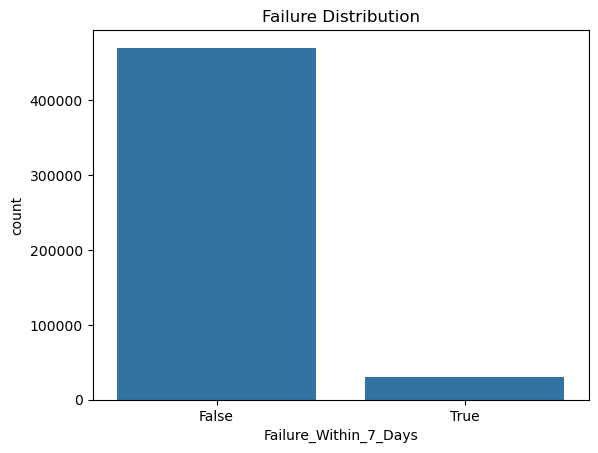

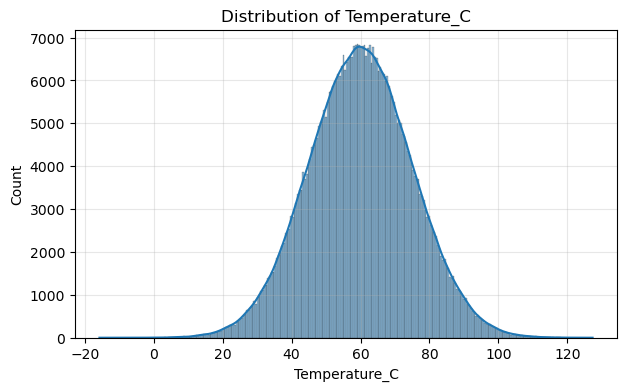

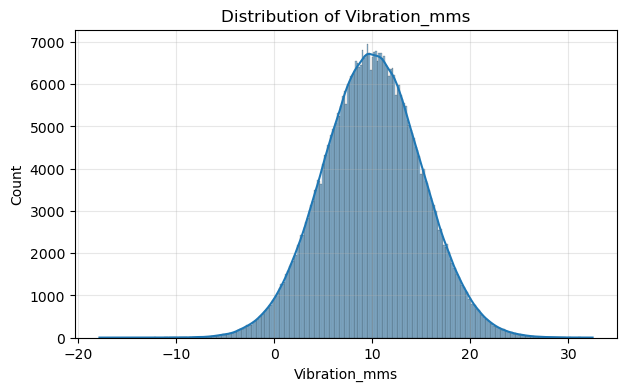

In [13]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix ,classification_report 
import pickle


# 1. Load the dataset
df = pd.read_csv('factory_sensor_simulator_2040.csv')

# 2. Select important columns
cols_to_keep = [
    'Machine_Type', 
    'Temperature_C', 
    'Vibration_mms', 
    'Power_Consumption_kW', 
    'Remaining_Useful_Life_days', 
    'Failure_Within_7_Days'
]

new_df = df[cols_to_keep]

# 3. Dataset inspection
print("Dataset Shape:", new_df.shape)
print(new_df.info())
print(new_df.describe())

# 4. Missing values
print("Missing values:\n", new_df.isnull().sum())

# 5. Target variable distribution
sns.countplot(x='Failure_Within_7_Days', data=new_df)
plt.title("Failure Distribution")
plt.show()

# 6. Histogram plotting function
def plot_histogram(df_input, column_name):
    plt.figure(figsize=(7,4))
    sns.histplot(data=df_input, x=column_name, kde=True)
    plt.title(f"Distribution of {column_name}")
    plt.grid(alpha=0.3)
    plt.show()

# 7. Generate plots
plot_histogram(new_df, "Temperature_C")
plot_histogram(new_df, "Vibration_mms")


In [14]:
# 1. Define Features and Target
X = new_df.drop('Failure_Within_7_Days', axis=1)
y = new_df['Failure_Within_7_Days']


# 2. Encode categorical variable
le = LabelEncoder()
X['Machine_Type'] = le.fit_transform(X['Machine_Type'])


# 3. Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 4. Handle class imbalance (SMOTE ONLY on training data)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


# 5. Model Definitions
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}


# 6. Train and Evaluate Models
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("\n", name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


# 7. Save Best Model (Example: Random Forest)

best_model = models["Random Forest"]

with open('pdm_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('encoder_pdm.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Training complete. Model and Encoder saved.")


 Decision Tree
Accuracy: 1.0
[[94040     0]
 [    0  5960]]
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     94040
        True       1.00      1.00      1.00      5960

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000


 Random Forest
Accuracy: 1.0
[[94040     0]
 [    0  5960]]
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     94040
        True       1.00      1.00      1.00      5960

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



C:\Users\Admin\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:06:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost
Accuracy: 0.9992
[[93988    52]
 [   28  5932]]
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     94040
        True       0.99      1.00      0.99      5960

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000

Training complete. Model and Encoder saved.


Model Accuracy: 0.9992

Classification Report:
              precision    recall  f1-score   support

       False       1.00      1.00      1.00     94040
        True       0.99      1.00      0.99      5960

    accuracy                           1.00    100000
   macro avg       1.00      1.00      1.00    100000
weighted avg       1.00      1.00      1.00    100000



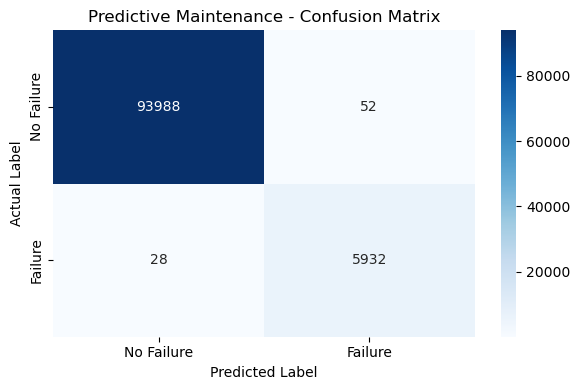

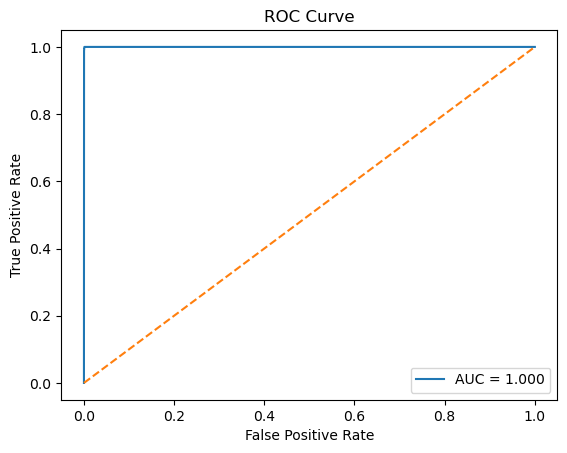

In [15]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Failure', 'Failure'],
    yticklabels=['No Failure', 'Failure']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Predictive Maintenance - Confusion Matrix')
plt.tight_layout()
plt.show()

from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [16]:
# Load model and encoder once
with open('pdm_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('encoder_pdm.pkl', 'rb') as f:
    loaded_encoder = pickle.load(f)


def maintenance_predictive_system(m_type, temp, vib, power):

    # Encode machine type
    try:
        m_type_encoded = loaded_encoder.transform([m_type])[0]
    except ValueError:
        print(f"Warning: {m_type} is a new machine type.")
        m_type_encoded = 0

    # Create input dataframe (same format as training)
    input_data = pd.DataFrame({
        "Machine_Type":[m_type_encoded],
        "Temperature_C":[temp],
        "Vibration_mms":[vib],
        "Power_Consumption_kW":[power]
    })

    # Prediction
    prediction = loaded_model.predict(input_data)[0]
    probability = loaded_model.predict_proba(input_data)[0][1]

    # Result
    if prediction == 1:
        return f"⚠️ ALERT: High Risk of Failure! Probability = {probability:.2%}"
    else:
        return f"✅ System Stable. Failure Risk = {probability:.2%}"